## load MIMIC-IV ECG dataset

In [2]:
import pandas as pd

# ────────────────────────────────────────────────────────────────
# Load all 3 MIMIC-IV ECG files
# ────────────────────────────────────────────────────────────────
BASE = r'D:\clinical text dataset\mimic-iv-ecg'

print("Loading MIMIC-IV ECG files...")

# 1. Waveform-Note links
waveform_links = pd.read_csv(f'{BASE}\\waveform_note_links.csv')
print(f"\n1. waveform_note_links.csv")
print(f"   Shape   : {waveform_links.shape}")
print(f"   Columns : {waveform_links.columns.tolist()}")
print(f"   Sample  :\n{waveform_links.head(3)}")

# 2. Record list
record_list = pd.read_csv(f'{BASE}\\record_list.csv')
print(f"\n2. record_list.csv")
print(f"   Shape   : {record_list.shape}")
print(f"   Columns : {record_list.columns.tolist()}")
print(f"   Sample  :\n{record_list.head(3)}")

# 3. Machine measurements
machine = pd.read_csv(f'{BASE}\\machine_measurements.csv')
print(f"\n3. machine_measurements.csv")
print(f"   Shape   : {machine.shape}")
print(f"   Columns : {machine.columns.tolist()}")
print(f"   Sample  :\n{machine.head(3)}")

Loading MIMIC-IV ECG files...

1. waveform_note_links.csv
   Shape   : (609272, 6)
   Columns : ['subject_id', 'study_id', 'waveform_path', 'note_id', 'note_seq', 'charttime']
   Sample  :
   subject_id  study_id                             waveform_path  \
0    10000032  40689238  files/p1000/p10000032/s40689238/40689238   
1    10000032  44458630  files/p1000/p10000032/s44458630/44458630   
2    10000032  49036311  files/p1000/p10000032/s49036311/49036311   

         note_id  note_seq            charttime  
0  10000032-EK-4         4  2180-07-23 08:44:00  
1  10000032-EK-5         5  2180-07-23 09:54:00  
2  10000032-EK-6         6  2180-08-06 09:07:00  

2. record_list.csv
   Shape   : (800035, 5)
   Columns : ['subject_id', 'study_id', 'file_name', 'ecg_time', 'path']
   Sample  :
   subject_id  study_id  file_name             ecg_time  \
0    10000032  40689238   40689238  2180-07-23 08:44:00   
1    10000032  44458630   44458630  2180-07-23 09:54:00   
2    10000032  49036311   

D:\temp\ipykernel_23936\570739719.py:25: DtypeWarning: Columns (16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  machine = pd.read_csv(f'{BASE}\\machine_measurements.csv')


In [ ]:
# ────────────────────────────────────────────────────────────────
# Deep dive — analysis of all files
# ────────────────────────────────────────────────────────────────

print("=" * 55)
print("WAVEFORM NOTE LINKS — Analysis")
print("=" * 55)
print(f"Unique subject_id : {waveform_links['subject_id'].nunique():,}")
print(f"Null values       :\n{waveform_links.isnull().sum()}")
print(f"\nDtype:\n{waveform_links.dtypes}")

print("\n" + "=" * 55)
print("RECORD LIST — Analysis")
print("=" * 55)
print(f"Unique subject_id : {record_list['subject_id'].nunique():,}")
print(f"Null values       :\n{record_list.isnull().sum()}")
print(f"\nDtype:\n{record_list.dtypes}")

print("\n" + "=" * 55)
print("MACHINE MEASUREMENTS — Analysis")
print("=" * 55)
print(f"Unique subject_id : {machine['subject_id'].nunique():,}")
print(f"Null values       :\n{machine.isnull().sum()}")
print(f"\nAll columns:\n{machine.columns.tolist()}")
print(f"\nDtype:\n{machine.dtypes}")

# Machine measurements stats
print(f"\nNumerical stats:")
print(machine.describe().round(2))

WAVEFORM NOTE LINKS — Analysis
Unique subject_id : 105,293
Null values       :
subject_id       0
study_id         0
waveform_path    0
note_id          0
note_seq         0
charttime        0
dtype: int64

Dtype:
subject_id        int64
study_id          int64
waveform_path    object
note_id          object
note_seq          int64
charttime        object
dtype: object

RECORD LIST — Analysis
Unique subject_id : 161,352
Null values       :
subject_id    0
study_id      0
file_name     0
ecg_time      0
path          0
dtype: int64

Dtype:
subject_id     int64
study_id       int64
file_name      int64
ecg_time      object
path          object
dtype: object

MACHINE MEASUREMENTS — Analysis
Unique subject_id : 53,216
Null values       :
subject_id          0
study_id            0
cart_id             0
ecg_time            0
report_0            1
report_1        65703
report_2        89946
report_3       134367
report_4       188916
report_5       223860
report_6       245836
report_7      

In [ ]:
# ────────────────────────────────────────────────────────────────
# Most important — in machine_measurements 
# is cardiac label present
# ────────────────────────────────────────────────────────────────

print("Checking cardiac-related columns in machine_measurements...")

# find Possible label columns 
cardiac_cols = [col for col in machine.columns
                if any(kw in col.lower() for kw in [
                    'rhythm', 'afib', 'flutter', 'block',
                    'label', 'diagnosis', 'report',
                    'tachycardia', 'bradycardia', 'normal',
                    'pr', 'qrs', 'qt', 'rate'
                ])]

print(f"\nCardiac-related columns found: {len(cardiac_cols)}")
for col in cardiac_cols:
    print(f"\n  Column: {col}")
    print(f"  Unique values: {machine[col].nunique()}")
    print(f"  Sample: {machine[col].value_counts().head(5).to_dict()}")

Checking cardiac-related columns in machine_measurements...

Cardiac-related columns found: 21

  Column: report_0
  Unique values: 1188
  Sample: {'Sinus rhythm': 104789, 'Sinus rhythm.': 19919, 'Sinus bradycardia': 19168, 'Sinus tachycardia': 13701, 'Atrial fibrillation': 10596}

  Column: report_1
  Unique values: 1565
  Sample: {'Left axis deviation': 21470, 'Prolonged QT interval': 9781, 'Leftward axis': 9385, 'Poor R wave progression - probable normal variant': 7448, 'Right bundle branch block': 6304}

  Column: report_2
  Unique values: 1194
  Sample: {'Normal ECG': 36586, 'Normal ECG except for rate': 11294, 'RBBB with left anterior fascicular block': 5878, 'IV conduction defect': 5866, 'Inferior infarct - age undetermined': 4962}

  Column: report_3
  Unique values: 948
  Sample: {'Borderline ECG': 34210, 'Abnormal ECG': 29877, 'Low QRS voltages in precordial leads': 3759, 'Inferior infarct - age undetermined': 3657, 'Left ventricular hypertrophy': 2770}

  Column: report_4
  

In [ ]:
# ────────────────────────────────────────────────────────────────
# Link check — how many patients commom in all 3
# ────────────────────────────────────────────────────────────────

wl_patients = set(waveform_links['subject_id'].astype(str))
rl_patients = set(record_list['subject_id'].astype(str))
mm_patients = set(machine['subject_id'].astype(str))

print("Patient overlap analysis:")
print(f"  waveform_links patients : {len(wl_patients):,}")
print(f"  record_list patients    : {len(rl_patients):,}")
print(f"  machine_measurements    : {len(mm_patients):,}")

# Common in all 3
common_all = wl_patients & rl_patients & mm_patients
print(f"\n  Common in all 3        : {len(common_all):,}")

# Overlap with MIMIC-IV notes 
cardiac_notes = pd.read_csv('cardiac_discharge_clean.csv', dtype=str)
notes_patients = set(cardiac_notes['subject_id'].astype(str))
print(f"  Cardiac notes patients : {len(notes_patients):,}")

# Final linkable patients
linkable = common_all & notes_patients
print(f"\n Fully linkable patients: {len(linkable):,}")
print(f"  (ECG + Notes + Measurements — same patient)")

Patient overlap analysis:
  waveform_links patients : 105,293
  record_list patients    : 161,352
  machine_measurements    : 53,216

  Common in all 3        : 34,644
  Cardiac notes patients : 67,351

  ✅ Fully linkable patients: 17,592
  (ECG + Notes + Measurements — same patient)


In [7]:
import pandas as pd
import numpy as np

BASE = r'D:\clinical text dataset\mimic-iv-ecg'

# Reload with low_memory fix
machine = pd.read_csv(
    f'{BASE}\\machine_measurements.csv',
    low_memory=False
)
waveform_links = pd.read_csv(f'{BASE}\\waveform_note_links.csv')
cardiac_notes  = pd.read_csv('cardiac_discharge_clean.csv', dtype=str)

print(f"Machine     : {machine.shape}")
print(f"Links       : {waveform_links.shape}")
print(f"Notes       : {cardiac_notes.shape}")

Machine     : (264864, 33)
Links       : (609272, 6)
Notes       : (131390, 4)


In [8]:
# ────────────────────────────────────────────────────────────────
# Step 2: Label mapping — clinically valid
# ────────────────────────────────────────────────────────────────

def assign_label(row):
    """
    report_0 + report_1 se primary arrhythmia label
    """
    r0 = str(row.get('report_0', '')).lower()
    r1 = str(row.get('report_1', '')).lower()
    r2 = str(row.get('report_2', '')).lower()
    combined = f"{r0} {r1} {r2}"

    # Priority order — most severe first
    if any(x in combined for x in [
        'ventricular fibrillation', 'ventricular flutter'
    ]):
        return 'VF'          # Most dangerous

    if any(x in combined for x in [
        'ventricular tachycardia'
    ]):
        return 'VT'

    if any(x in combined for x in [
        'atrial fibrillation', 'afib', 'a fib'
    ]):
        return 'AFIB'

    if any(x in combined for x in [
        'atrial flutter'
    ]):
        return 'AFL'

    if any(x in combined for x in [
        'supraventricular tachycardia', 'svt'
    ]):
        return 'SVT'

    if any(x in combined for x in [
        'heart block', 'av block', 'bundle branch block',
        'left bundle', 'right bundle'
    ]):
        return 'BLOCK'

    if any(x in combined for x in [
        'sinus tachycardia'
    ]):
        return 'STACH'

    if any(x in combined for x in [
        'sinus bradycardia'
    ]):
        return 'SBRAD'

    if any(x in combined for x in [
        'sinus rhythm', 'normal ecg', 'normal sinus'
    ]):
        return 'NORMAL'

    return 'OTHER'

machine['arrhythmia_label'] = machine.apply(assign_label, axis=1)

print("Label distribution:")
print(machine['arrhythmia_label'].value_counts())
print(f"\nTotal labeled: {len(machine):,}")
print(f"OTHER count  : {(machine['arrhythmia_label']=='OTHER').sum():,}")

Label distribution:
arrhythmia_label
NORMAL    144759
SBRAD      30139
AFIB       26889
STACH      22303
OTHER      20951
BLOCK      14826
AFL         4423
VT           574
Name: count, dtype: int64

Total labeled: 264,864
OTHER count  : 20,951


In [11]:
# Actual column names dekho
print("All columns in machine_measurements:")
for col in machine.columns:
    print(f"  '{col}'")

All columns in machine_measurements:
  'subject_id'
  'study_id'
  'cart_id'
  'ecg_time'
  'report_0'
  'report_1'
  'report_2'
  'report_3'
  'report_4'
  'report_5'
  'report_6'
  'report_7'
  'report_8'
  'report_9'
  'report_10'
  'report_11'
  'report_12'
  'report_13'
  'report_14'
  'report_15'
  'report_16'
  'report_17'
  'bandwidth'
  'filtering'
  'rr_interval'
  'p_onset'
  'p_end'
  'qrs_onset'
  'qrs_end'
  't_end'
  'p_axis'
  'qrs_axis'
  't_axis'
  'arrhythmia_label'


In [15]:
# Exact columns dekhte hain — truncation ke bina
print("Machine measurements — ALL columns:")
print(machine.columns.tolist())

Machine measurements — ALL columns:
['subject_id', 'study_id', 'cart_id', 'ecg_time', 'report_0', 'report_1', 'report_2', 'report_3', 'report_4', 'report_5', 'report_6', 'report_7', 'report_8', 'report_9', 'report_10', 'report_11', 'report_12', 'report_13', 'report_14', 'report_15', 'report_16', 'report_17', 'bandwidth', 'filtering', 'rr_interval', 'p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis', 't_axis', 'arrhythmia_label']


In [16]:
# ────────────────────────────────────────────────────────────────
# Step 3: Correct columns use karo
# ────────────────────────────────────────────────────────────────

machine['subject_id']        = machine['subject_id'].astype(str)
waveform_links['subject_id'] = waveform_links['subject_id'].astype(str)
cardiac_notes['subject_id']  = cardiac_notes['subject_id'].astype(str)

# Sirf jo columns actually hain
ecg_labeled = machine[['subject_id', 'study_id',
                        'arrhythmia_label',
                        'rr_interval',
                        'qrs_onset', 'qrs_end',
                        'p_onset',   'p_end',
                        't_end',
                        'qrs_axis',  'p_axis', 't_axis',
                        'report_0']].copy()

ecg_labeled['study_id']    = ecg_labeled['study_id'].astype(str)
waveform_links['study_id'] = waveform_links['study_id'].astype(str)

# Merge: ECG labels + note_id
linked = ecg_labeled.merge(
    waveform_links[['subject_id', 'study_id', 'note_id']],
    on  = ['subject_id', 'study_id'],
    how = 'inner'
)
print(f"After ECG-Note link : {len(linked):,} rows")
print(f"Unique patients     : {linked['subject_id'].nunique():,}")

# Discharge notes add karo
final_df = linked.merge(
    cardiac_notes[['subject_id', 'note_id', 'text_clean']],
    on  = ['subject_id', 'note_id'],
    how = 'inner'
)

print(f"\nFinal linked dataset: {len(final_df):,} rows")
print(f"Unique patients     : {final_df['subject_id'].nunique():,}")
print(f"\nLabel distribution:")
print(final_df['arrhythmia_label'].value_counts())

After ECG-Note link : 202,082 rows
Unique patients     : 34,644

Final linked dataset: 0 rows
Unique patients     : 0

Label distribution:
Series([], Name: count, dtype: int64)


In [18]:
# note_id format check karo dono mein
print("cardiac_notes note_id sample:")
print(cardiac_notes['note_id'].head(10).tolist())
print(f"dtype: {cardiac_notes['note_id'].dtype}")

print("\nlinked note_id sample:")
print(linked['note_id'].head(10).tolist())
print(f"dtype: {linked['note_id'].dtype}")

# Common note_ids check karo
notes_ids  = set(cardiac_notes['note_id'].astype(str))
linked_ids = set(linked['note_id'].astype(str))
common     = notes_ids & linked_ids
print(f"\nCardiac notes note_ids  : {len(notes_ids):,}")
print(f"Linked note_ids         : {len(linked_ids):,}")
print(f"Common note_ids         : {len(common):,}")

cardiac_notes note_id sample:
['10000032-DS-23', '10000826-DS-17', '10000826-DS-19', '10000935-DS-21', '10000980-DS-20', '10000980-DS-26', '10001401-DS-19', '10001667-DS-10', '10001877-DS-19', '10001877-DS-20']
dtype: object

linked note_id sample:
['10000032-EK-4', '10000032-EK-5', '10000032-EK-6', '10000117-EK-17', '10000560-EK-12', '10000635-EK-12', '10000635-EK-14', '10000635-EK-15', '10000635-EK-16', '10000635-EK-17']
dtype: object

Cardiac notes note_ids  : 131,390
Linked note_ids         : 202,082
Common note_ids         : 0


In [19]:
# ────────────────────────────────────────────────────────────────
# Correct approach — subject_id se join
# ────────────────────────────────────────────────────────────────

# Step 1: One discharge note per patient — latest wala
cardiac_notes_dedup = cardiac_notes.sort_values(
    'note_id'
).groupby('subject_id').last().reset_index()

print(f"Cardiac notes (1 per patient): {len(cardiac_notes_dedup):,}")

# Step 2: ECG labeled — one record per patient — latest wala  
ecg_per_patient = ecg_labeled.sort_values(
    'study_id'
).groupby('subject_id').last().reset_index()

print(f"ECG records (1 per patient)  : {len(ecg_per_patient):,}")

# Step 3: subject_id se join
final_df = ecg_per_patient.merge(
    cardiac_notes_dedup[['subject_id', 'note_id', 'text_clean']],
    on  = 'subject_id',
    how = 'inner'
)

print(f"\nFinal linked : {len(final_df):,} rows")
print(f"Unique patients: {final_df['subject_id'].nunique():,}")
print(f"\nLabel distribution:")
print(final_df['arrhythmia_label'].value_counts())

Cardiac notes (1 per patient): 67,351
ECG records (1 per patient)  : 53,216

Final linked : 20,266 rows
Unique patients: 20,266

Label distribution:
arrhythmia_label
NORMAL    9904
AFIB      2744
STACH     2377
SBRAD     2066
OTHER     1570
BLOCK     1179
AFL        380
VT          46
Name: count, dtype: int64


In [20]:
# ────────────────────────────────────────────────────────────────
# Clean + Save
# ────────────────────────────────────────────────────────────────

final_clean = final_df[
    final_df['arrhythmia_label'] != 'OTHER'
].reset_index(drop=True)

print(f"After removing OTHER: {len(final_clean):,} rows")
print(f"Unique patients     : {final_clean['subject_id'].nunique():,}")
print(f"\nFinal label counts:")
print(final_clean['arrhythmia_label'].value_counts())

# Save
final_clean.to_csv('mimic_ecg_notes_linked.csv', index=False)
print(f"\nSaved: mimic_ecg_notes_linked.csv")
print(f"Shape : {final_clean.shape}")

# Sample
print("\n── Sample row ──")
row = final_clean.iloc[0]
print(f"Subject   : {row['subject_id']}")
print(f"Label     : {row['arrhythmia_label']}")
print(f"Report    : {row['report_0']}")
print(f"Text(200) : {str(row['text_clean'])[:200]}")

After removing OTHER: 18,696 rows
Unique patients     : 18,696

Final label counts:
arrhythmia_label
NORMAL    9904
AFIB      2744
STACH     2377
SBRAD     2066
BLOCK     1179
AFL        380
VT          46
Name: count, dtype: int64

Saved: mimic_ecg_notes_linked.csv
Shape : (18696, 15)

── Sample row ──
Subject   : 10000032
Label     : STACH
Report    : Sinus tachycardia
Text(200) : allergies: percocet / vicodin altered mental status major surgical or invasive procedure: none history of present illness: mrs. is a female with hiv on haart, copd, hcv cirrhosis complicated by ascite


In [21]:
# ────────────────────────────────────────────────────────────────
# Label consolidation — IEEE ke liye clinically meaningful
# ────────────────────────────────────────────────────────────────

final_clean = pd.read_csv('mimic_ecg_notes_linked.csv', dtype=str)

# 3-class consolidation — clinically justified
def consolidate_label(label):
    if label == 'NORMAL':
        return 'NORMAL'          # Low risk
    elif label in ['STACH', 'SBRAD', 'BLOCK']:
        return 'MILD'            # Moderate risk
    elif label in ['AFIB', 'AFL', 'VT']:
        return 'SEVERE'          # High risk
    return None

final_clean['risk_label'] = final_clean['arrhythmia_label'].apply(
    consolidate_label
)

print("3-class risk distribution:")
print(final_clean['risk_label'].value_counts())
print(f"\nTotal: {len(final_clean):,}")

# Class balance check
counts = final_clean['risk_label'].value_counts()
total  = len(final_clean)
print(f"\nPercentages:")
for cls, cnt in counts.items():
    print(f"  {cls:<8}: {cnt:,}  ({cnt/total*100:.1f}%)")

final_clean.to_csv('mimic_ecg_notes_linked.csv', index=False)
print("\nSaved with risk_label!")

3-class risk distribution:
risk_label
NORMAL    9904
MILD      5622
SEVERE    3170
Name: count, dtype: int64

Total: 18,696

Percentages:
  NORMAL  : 9,904  (53.0%)
  MILD    : 5,622  (30.1%)
  SEVERE  : 3,170  (17.0%)

Saved with risk_label!


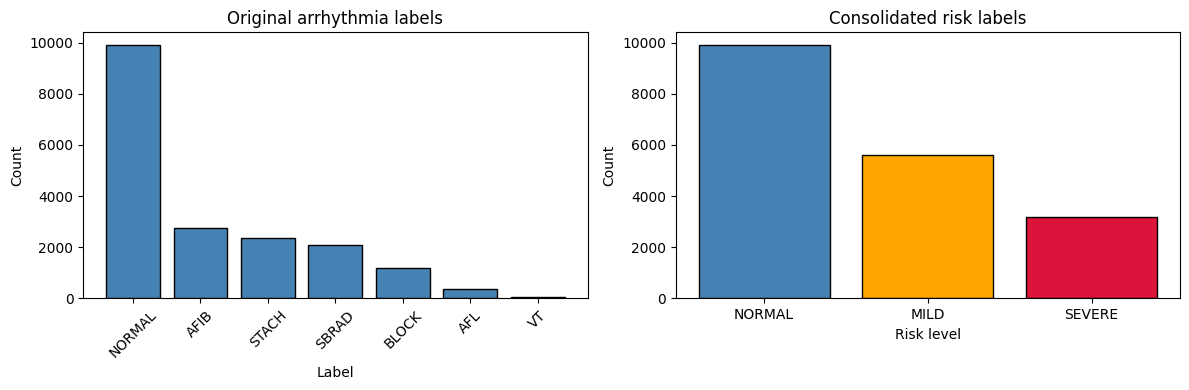


── Dataset Summary (IEEE Table 1) ──
Total patients    : 18,696
Total records     : 18,696
Features          : ECG intervals + Clinical notes
Text avg length   : 11132 chars

Risk label counts:
risk_label
NORMAL    9904
MILD      5622
SEVERE    3170
Name: count, dtype: int64


In [22]:
# ────────────────────────────────────────────────────────────────
# Dataset summary — IEEE paper ke liye table ready
# ────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

df = pd.read_csv('mimic_ecg_notes_linked.csv', dtype=str)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original labels
orig_counts = df['arrhythmia_label'].value_counts()
axes[0].bar(orig_counts.index, orig_counts.values,
            color='steelblue', edgecolor='black')
axes[0].set_title('Original arrhythmia labels')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Risk labels
risk_counts = df['risk_label'].value_counts()
colors = ['steelblue', 'orange', 'crimson']
axes[1].bar(risk_counts.index, risk_counts.values,
            color=colors, edgecolor='black')
axes[1].set_title('Consolidated risk labels')
axes[1].set_xlabel('Risk level')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()

print("\n── Dataset Summary (IEEE Table 1) ──")
print(f"Total patients    : {df['subject_id'].nunique():,}")
print(f"Total records     : {len(df):,}")
print(f"Features          : ECG intervals + Clinical notes")
print(f"Text avg length   : {df['text_clean'].str.len().astype(float).mean():.0f} chars")
print(f"\nRisk label counts:")
print(df['risk_label'].value_counts())

In [23]:
import pandas as pd

# Linked dataset load karo
df = pd.read_csv('mimic_ecg_notes_linked.csv', dtype=str)
print(f"Patients: {len(df):,}")

BASE = r'D:\clinical text dataset\mimic-iv-ecg'

# Waveform links load karo
waveform_links = pd.read_csv(
    f'{BASE}\\waveform_note_links.csv', dtype=str
)

# 18,696 patients ke waveform paths nikalo
our_patients = set(df['subject_id'].astype(str))

patient_waveforms = waveform_links[
    waveform_links['subject_id'].astype(str).isin(our_patients)
].drop_duplicates(subset=['subject_id', 'study_id'])

print(f"\nWaveform records for our patients: {len(patient_waveforms):,}")
print(f"Unique patients                  : {patient_waveforms['subject_id'].nunique():,}")
print(f"\nSample waveform paths:")
print(patient_waveforms['waveform_path'].head(5).tolist())

# One waveform per patient — latest study
patient_waveforms_dedup = (
    patient_waveforms
    .sort_values('study_id')
    .groupby('subject_id')
    .last()
    .reset_index()
)

print(f"\nOne waveform per patient: {len(patient_waveforms_dedup):,}")

# Save paths list
patient_waveforms_dedup.to_csv(
    'waveform_paths_to_download.csv', index=False
)
print("Saved: waveform_paths_to_download.csv")
print(f"\nSample paths:")
print(patient_waveforms_dedup['waveform_path'].head(3).tolist())

Patients: 18,696

Waveform records for our patients: 141,456
Unique patients                  : 16,203

Sample waveform paths:
['files/p1000/p10000032/s40689238/40689238', 'files/p1000/p10000032/s44458630/44458630', 'files/p1000/p10000032/s49036311/49036311', 'files/p1000/p10000826/s40695233/40695233', 'files/p1000/p10000826/s40894787/40894787']

One waveform per patient: 16,203
Saved: waveform_paths_to_download.csv

Sample paths:
['files/p1000/p10000032/s49036311/49036311', 'files/p1000/p10000826/s40894787/40894787', 'files/p1000/p10000935/s48582094/48582094']


## important ECG waveform dataset download 

In [ ]:
import requests
import os

username = "sakshi-yadav06"
password = "Sakshi@123"  

# download a sample waveform for check
sample_path = 'files/p1000/p10000032/s49036311/49036311'
base_url    = 'https://physionet.org/files/mimic-iv-ecg/1.0/'

# WFDB format has 2 files — .hea and .dat
save_dir = r'D:\clinical text dataset\mimic-iv-ecg\waveforms\test'
os.makedirs(save_dir, exist_ok=True)

for ext in ['.hea', '.dat']:
    url      = base_url + sample_path + ext
    filename = sample_path.split('/')[-1] + ext
    r        = requests.get(url, auth=(username, password))

    if r.status_code == 200:
        with open(os.path.join(save_dir, filename), 'wb') as f:
            f.write(r.content)
        print(f"Downloaded: {filename} ({len(r.content)/1024:.1f} KB)")
    else:
        print(f"Failed: {filename} — {r.status_code}")

✅ Downloaded: 49036311.hea (0.6 KB)
✅ Downloaded: 49036311.dat (117.2 KB)


Signal shape  : (5000, 12)
Sampling rate : 500 Hz
Leads         : ['I', 'II', 'III', 'aVR', 'aVF', 'aVL', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Duration      : 10.0 seconds


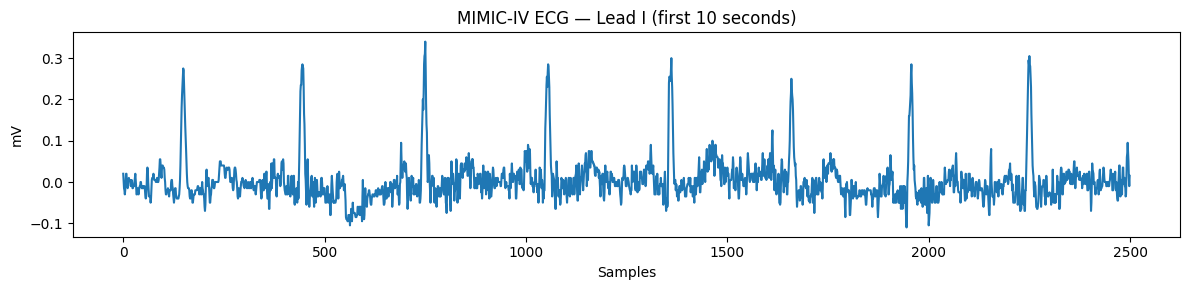

In [26]:
# Test downloaded waveform
import wfdb
import matplotlib.pyplot as plt

test_path = r'D:\clinical text dataset\mimic-iv-ecg\waveforms\test\49036311'
record    = wfdb.rdrecord(test_path)

print(f"Signal shape  : {record.p_signal.shape}")
print(f"Sampling rate : {record.fs} Hz")
print(f"Leads         : {record.sig_name}")
print(f"Duration      : {record.p_signal.shape[0]/record.fs:.1f} seconds")

# Plot
plt.figure(figsize=(12, 3))
plt.plot(record.p_signal[:2500, 0])
plt.title('MIMIC-IV ECG — Lead I (first 10 seconds)')
plt.xlabel('Samples')
plt.ylabel('mV')
plt.tight_layout()
plt.show()

In [28]:
import pandas as pd
import requests
import os
from tqdm import tqdm
import time

username = "sakshi-yadav06"
password = "Sakshi@123"

BASE_URL = 'https://physionet.org/files/mimic-iv-ecg/1.0/'
SAVE_DIR = r'D:\clinical text dataset\mimic-iv-ecg\waveforms'
os.makedirs(SAVE_DIR, exist_ok=True)

# Load paths
paths_df = pd.read_csv('waveform_paths_to_download.csv', dtype=str)
print(f"Total to download: {len(paths_df):,} patients")
print(f"Estimated size   : ~{len(paths_df)*117/1024:.1f} GB")

# Resume support — already downloaded check
already_done = set()
for root, dirs, files in os.walk(SAVE_DIR):
    for f in files:
        if f.endswith('.hea'):
            already_done.add(f.replace('.hea', ''))

print(f"Already downloaded: {len(already_done):,}")
print(f"Remaining         : {len(paths_df) - len(already_done):,}")

Total to download: 16,203 patients
Estimated size   : ~1851.3 GB
Already downloaded: 1
Remaining         : 16,202


In [29]:
# ── Bulk download with resume
failed = []
success = 0

session = requests.Session()
session.auth = (username, password)

for _, row in tqdm(paths_df.iterrows(), total=len(paths_df)):
    wf_path  = row['waveform_path']
    filename = wf_path.split('/')[-1]

    # Skip already downloaded
    if filename in already_done:
        success += 1
        continue

    # Patient folder banao
    patient_dir = os.path.join(SAVE_DIR, row['subject_id'])
    os.makedirs(patient_dir, exist_ok=True)
    save_path   = os.path.join(patient_dir, filename)

    # Download .hea + .dat
    ok = True
    for ext in ['.hea', '.dat']:
        url = BASE_URL + wf_path + ext
        try:
            r = session.get(url, timeout=30)
            if r.status_code == 200:
                with open(save_path + ext, 'wb') as f:
                    f.write(r.content)
            else:
                ok = False
                break
        except Exception as e:
            ok = False
            break

    if ok:
        success += 1
        already_done.add(filename)
    else:
        failed.append(wf_path)

    # Rate limiting
    time.sleep(0.05)

    # Progress save every 500
    if success % 500 == 0:
        print(f"  ✅ {success:,} done | ❌ {len(failed):,} failed")

print(f"\nDone!")
print(f"Success : {success:,}")
print(f"Failed  : {len(failed):,}")

if failed:
    pd.DataFrame({'path': failed}).to_csv(
        'failed_downloads.csv', index=False
    )
    print("Failed paths saved: failed_downloads.csv")

  3%|▎         | 500/16203 [15:43<10:51:59,  2.49s/it]

  ✅ 500 done | ❌ 0 failed


  6%|▌         | 1000/16203 [34:12<11:23:05,  2.70s/it]

  ✅ 1,000 done | ❌ 0 failed


  9%|▉         | 1500/16203 [52:04<9:10:18,  2.25s/it] 

...

  ✅ 15,500 done | ❌ 0 failed


 99%|█████████▊| 16000/16203 [10:02:44<05:33,  1.64s/it]

  ✅ 16,000 done | ❌ 0 failed


100%|██████████| 16203/16203 [10:11:30<00:00,  2.26s/it]


Done!
Success : 16,203
Failed  : 0


In [30]:
import wfdb
import numpy as np
import pandas as pd
import os
from scipy.signal import butter, filtfilt

WAVE_DIR = r'D:\clinical text dataset\mimic-iv-ecg\waveforms'

# ── Quick verify — 5 random patients
paths_df = pd.read_csv('waveform_paths_to_download.csv', dtype=str)

print("Verifying downloaded waveforms...")
ok_count   = 0
fail_count = 0

for _, row in paths_df.sample(5, random_state=42).iterrows():
    filename   = row['waveform_path'].split('/')[-1]
    patient_dir = os.path.join(WAVE_DIR, row['subject_id'])
    full_path   = os.path.join(patient_dir, filename)

    try:
        rec = wfdb.rdrecord(full_path)
        print(f"  ✅ {filename} | shape={rec.p_signal.shape} | "
              f"fs={rec.fs} | leads={len(rec.sig_name)}")
        ok_count += 1
    except Exception as e:
        print(f"  ❌ {filename} | Error: {e}")
        fail_count += 1

print(f"\nOK: {ok_count} | Failed: {fail_count}")

The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.
Verifying downloaded waveforms...
  ✅ 42304927 | shape=(5000, 12) | fs=500 | leads=12
  ✅ 49954608 | shape=(5000, 12) | fs=500 | leads=12
  ✅ 47578939 | shape=(5000, 12) | fs=500 | leads=12
  ✅ 49375874 | shape=(5000, 12) | fs=500 | leads=12
  ✅ 49946650 | shape=(5000, 12) | fs=500 | leads=12

OK: 5 | Failed: 0


In [33]:
print(full_path)
print(os.path.exists(full_path + '.hea'))

D:\clinical text dataset\mimic-iv-ecg\waveforms\10014136\43108613
True


In [34]:
import wfdb
import numpy as np
import pandas as pd
import os
from scipy.signal import butter, filtfilt

WAVE_DIR = r'D:\clinical text dataset\mimic-iv-ecg\waveforms'

# ── Filter
def butter_bandpass(signal, fs=500, lowcut=0.5, highcut=40, order=4):
    nyq = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

# ── Loader
def load_ecg_segment(filepath, lead_idx=1, target_len=5000):
    rec = wfdb.rdrecord(filepath)
    signal = rec.p_signal[:, lead_idx]

    signal = np.nan_to_num(signal, nan=0.0)
    signal = butter_bandpass(signal, fs=rec.fs)

    if len(signal) >= target_len:
        signal = signal[:target_len]
    else:
        signal = np.pad(signal, (0, target_len - len(signal)))

    std = signal.std()
    if std > 0:
        signal = (signal - signal.mean()) / std

    return signal.astype(np.float32)

# ── Load paths
paths_df = pd.read_csv('waveform_paths_to_download.csv', dtype=str)

# ── SAFE TEST (existing file dhundo)
found = False

for _, row in paths_df.sample(50, random_state=42).iterrows():
    filename = row['waveform_path'].split('/')[-1]
    patient_dir = os.path.join(WAVE_DIR, row['subject_id'])
    full_path = os.path.join(patient_dir, filename)

    if os.path.exists(full_path + '.hea'):
        print(f"✅ Using file: {full_path}")
        
        sig = load_ecg_segment(full_path)
        
        print(f"Signal shape : {sig.shape}")
        print(f"Mean         : {sig.mean():.4f}")
        print(f"Std          : {sig.std():.4f}")
        print(f"Min/Max      : {sig.min():.3f} / {sig.max():.3f}")
        
        found = True
        break

if not found:
    print("❌ No valid file found (check download folder)")

✅ Using file: D:\clinical text dataset\mimic-iv-ecg\waveforms\12031879\42304927
Signal shape : (5000,)
Mean         : 0.0000
Std          : 1.0000
Min/Max      : -2.160 / 5.168


## EDA

In [36]:
#basic signal check
lengths = []

for _, row in paths_df.sample(100).iterrows():
    filename = row['waveform_path'].split('/')[-1]
    path = os.path.join(WAVE_DIR, row['subject_id'], filename)
    
    try:
        rec = wfdb.rdrecord(path)
        lengths.append(rec.p_signal.shape[0])
    except:
        pass

print("Min:", min(lengths))
print("Max:", max(lengths))
print("Mean:", sum(lengths)/len(lengths))

Min: 5000
Max: 5000
Mean: 5000.0


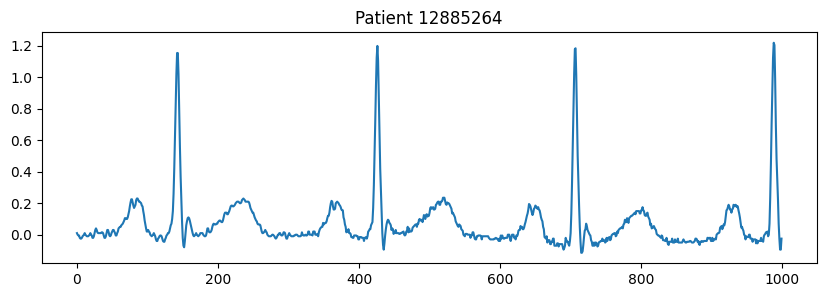

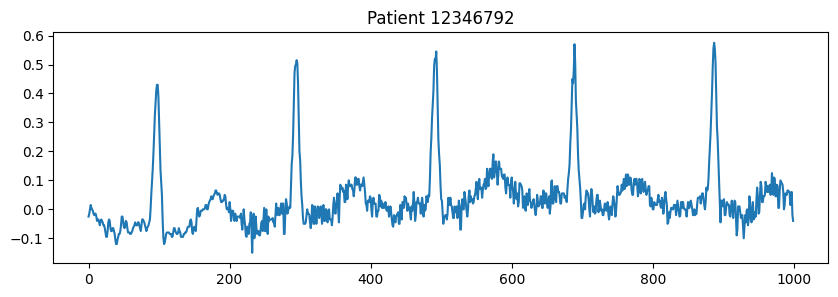

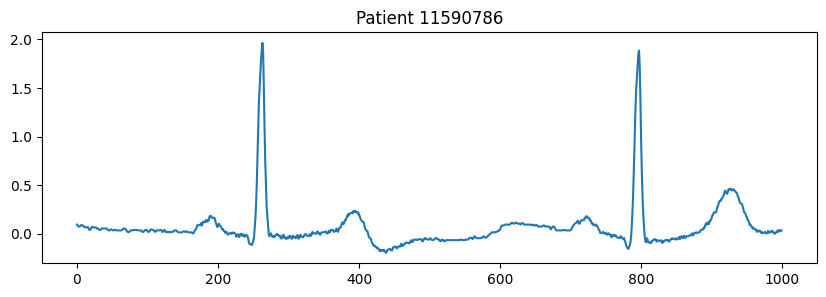

In [37]:
import matplotlib.pyplot as plt

for _, row in paths_df.sample(3).iterrows():
    filename = row['waveform_path'].split('/')[-1]
    path = os.path.join(WAVE_DIR, row['subject_id'], filename)

    rec = wfdb.rdrecord(path)
    signal = rec.p_signal[:, 1]  # Lead II

    plt.figure(figsize=(10,3))
    plt.plot(signal[:1000])
    plt.title(f"Patient {row['subject_id']}")
    plt.show()

In [38]:
signals = []

for _, row in paths_df.sample(100).iterrows():
    filename = row['waveform_path'].split('/')[-1]
    path = os.path.join(WAVE_DIR, row['subject_id'], filename)

    try:
        sig = load_ecg_segment(path)
        signals.append(sig)
    except:
        pass

signals = np.array(signals)

print("Shape:", signals.shape)
print("Mean:", signals.mean())
print("Std :", signals.std())

Shape: (100, 5000)
Mean: -4.348755e-10
Std : 1.0


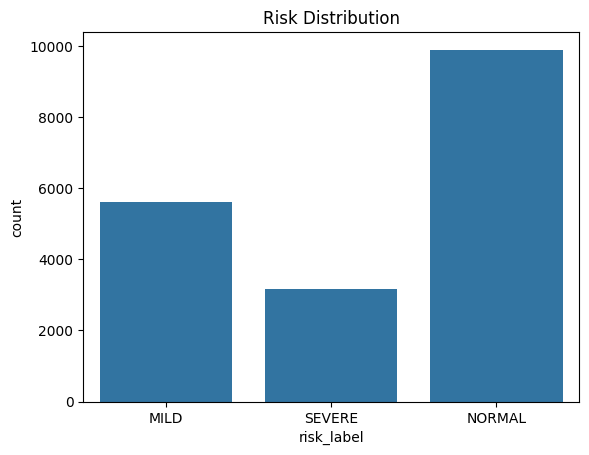

In [39]:
import seaborn as sns

sns.countplot(data=final_clean, x='risk_label')
plt.title("Risk Distribution")
plt.show()

In [45]:
print(final_clean.columns.tolist())

['subject_id', 'study_id', 'arrhythmia_label', 'rr_interval', 'qrs_onset', 'qrs_end', 'p_onset', 'p_end', 't_end', 'qrs_axis', 'p_axis', 't_axis', 'report_0', 'note_id', 'text_clean', 'risk_label', 'text_len']


In [42]:
final_clean['text_len'] = final_clean['text_clean'].apply(len)

print(final_clean['text_len'].describe())

count    18696.000000
mean     11131.971652
std       4348.282326
min       1966.000000
25%       8155.750000
50%      10413.000000
75%      13281.000000
max      54973.000000
Name: text_len, dtype: float64


In [43]:
missing = 0

for _, row in paths_df.iterrows():
    filename = row['waveform_path'].split('/')[-1]
    path = os.path.join(WAVE_DIR, row['subject_id'], filename)

    if not os.path.exists(path + ".hea"):
        missing += 1

print("Missing files:", missing)

Missing files: 1


In [50]:
import pandas as pd
import numpy as np

final_clean = pd.read_csv('mimic_ecg_notes_linked.csv', dtype=str)

# Raw values check
cols = ['p_onset', 'p_end', 'qrs_onset', 'qrs_end', 't_end', 'rr_interval']
for col in cols:
    final_clean[col] = pd.to_numeric(final_clean[col], errors='coerce')
    print(f"{col:15} | mean={final_clean[col].mean():.1f} | "
          f"min={final_clean[col].min():.1f} | "
          f"max={final_clean[col].max():.1f}")

p_onset         | mean=4815.3 | min=8.0 | max=29999.0
p_end           | mean=8832.1 | min=48.0 | max=29999.0
qrs_onset       | mean=239.4 | min=20.0 | max=555.0
qrs_end         | mean=337.7 | min=109.0 | max=763.0
t_end           | mean=630.6 | min=273.0 | max=1142.0
rr_interval     | mean=786.4 | min=239.0 | max=2500.0


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

final_clean = pd.read_csv('mimic_ecg_notes_linked.csv', dtype=str)

# Numeric convert
for col in ['p_onset', 'p_end', 'qrs_onset', 'qrs_end',
            't_end', 'rr_interval', 'qrs_axis', 'p_axis', 't_axis']:
    final_clean[col] = pd.to_numeric(final_clean[col], errors='coerce')

# ── heart_rate sirf rr_interval se — ye reliable hai
final_clean['heart_rate'] = 60000 / final_clean['rr_interval']

# ── Baaki directly raw values use karo — derive mat karo
# qrs_duration = qrs_end - qrs_onset (dono same scale pe hain)
final_clean['qrs_duration'] = (
    final_clean['qrs_end'] - final_clean['qrs_onset']
)

# qt_interval = t_end - qrs_onset (dono same scale pe hain)
final_clean['qt_interval'] = (
    final_clean['t_end'] - final_clean['qrs_onset']
)

# pr_interval — p_end use karo (p_onset nahi)
# p_end bhi large scale pe hai → skip karo
# Instead rr_interval based features use karo

print("Feature stats after fix:")
print(f"\nheart_rate:")
print(f"  Mean: {final_clean['heart_rate'].mean():.1f} bpm")
print(f"  Min : {final_clean['heart_rate'].min():.1f}")
print(f"  Max : {final_clean['heart_rate'].max():.1f}")

print(f"\nqrs_duration:")
print(f"  Mean: {final_clean['qrs_duration'].mean():.1f} ms")
print(f"  Min : {final_clean['qrs_duration'].min():.1f}")
print(f"  Max : {final_clean['qrs_duration'].max():.1f}")

print(f"\nqt_interval:")
print(f"  Mean: {final_clean['qt_interval'].mean():.1f} ms")
print(f"  Min : {final_clean['qt_interval'].min():.1f}")
print(f"  Max : {final_clean['qt_interval'].max():.1f}")

# Clinical validity
print(f"\nClinical check:")
print(f"  HR 40-200   : {final_clean['heart_rate'].between(40,200).sum():,}")
print(f"  QRS 60-200  : {final_clean['qrs_duration'].between(60,200).sum():,}")
print(f"  QT 300-600  : {final_clean['qt_interval'].between(300,600).sum():,}")

Feature stats after fix:

heart_rate:
  Mean: 81.8 bpm
  Min : 24.0
  Max : 251.0

qrs_duration:
  Mean: 98.3 ms
  Min : 30.0
  Max : 257.0

qt_interval:
  Mean: 391.2 ms
  Min : 189.0
  Max : 744.0

Clinical check:
  HR 40-200   : 18,626
  QRS 60-200  : 18,678
  QT 300-600  : 18,063


heart_rate     : 7 outliers → median
rr_interval    : 7 outliers → median
qrs_duration   : 3 outliers → median
qt_interval    : 3 outliers → median
qrs_axis       : 51 outliers → median
p_axis         : 3,266 outliers → median
t_axis         : 168 outliers → median


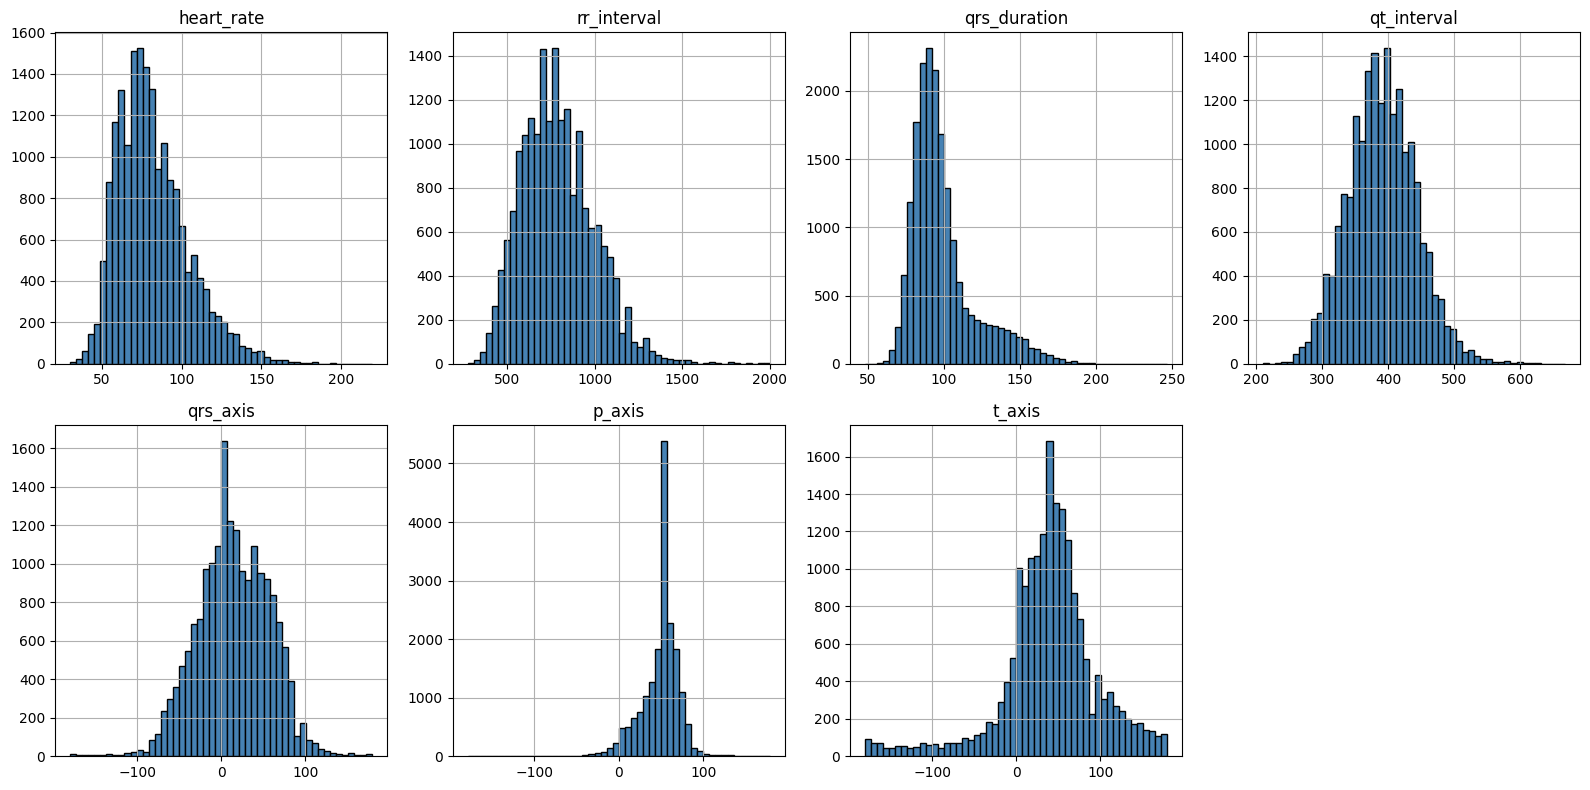


Final columns: ['subject_id', 'study_id', 'arrhythmia_label', 'rr_interval', 'qrs_onset', 'qrs_end', 'p_onset', 'p_end', 't_end', 'qrs_axis', 'p_axis', 't_axis', 'report_0', 'note_id', 'text_clean', 'risk_label', 'heart_rate', 'qrs_duration', 'qt_interval']
Shape: (18696, 19)


In [52]:
# ── Final feature set decide karo
# pr_interval reliable nahi — drop karo
# Use karo: heart_rate, qrs_duration, qt_interval,
#           rr_interval, qrs_axis, p_axis, t_axis

CLINICAL_FEATURES = [
    'heart_rate',    # bpm
    'rr_interval',   # ms — HRV indicator
    'qrs_duration',  # ms — conduction time
    'qt_interval',   # ms — repolarization
    'qrs_axis',      # degrees
    'p_axis',        # degrees
    't_axis',        # degrees
]

# Outlier handling — clinical ranges
ranges = {
    'heart_rate'  : (30,  250),
    'rr_interval' : (240, 2000),
    'qrs_duration': (40,  250),
    'qt_interval' : (200, 700),
    'qrs_axis'    : (-180, 180),
    'p_axis'      : (-180, 180),
    't_axis'      : (-180, 180),
}

for col, (lo, hi) in ranges.items():
    mask = ~final_clean[col].between(lo, hi)
    print(f"{col:<15}: {mask.sum():,} outliers → median")
    final_clean.loc[mask, col] = np.nan
    final_clean[col] = final_clean[col].fillna(
        final_clean[col].median()
    )

# Plot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, col in zip(axes.flatten(), CLINICAL_FEATURES):
    final_clean[col].hist(bins=50, ax=ax,
                          color='steelblue', edgecolor='black')
    ax.set_title(col)
axes[-1, -1].axis('off')
plt.tight_layout()
plt.savefig('clinical_features_final.png', dpi=150)
plt.show()

# Drop pr_interval — unreliable
if 'pr_interval' in final_clean.columns:
    final_clean = final_clean.drop(columns=['pr_interval'])

# Save
final_clean.to_csv('mimic_ecg_notes_linked.csv', index=False)
print(f"\nFinal columns: {final_clean.columns.tolist()}")
print(f"Shape: {final_clean.shape}")

In [56]:
import pandas as pd
import numpy as np
import wfdb
import os
import gc
from scipy.signal import butter, filtfilt
from tqdm import tqdm

WAVE_DIR = r'D:\clinical text dataset\mimic-iv-ecg\waveforms'

final_clean = pd.read_csv('mimic_ecg_notes_linked.csv', dtype=str)
paths_df    = pd.read_csv('waveform_paths_to_download.csv', dtype=str)

# Merge paths
df = final_clean.merge(
    paths_df[['subject_id', 'waveform_path']],
    on='subject_id', how='inner'
)
print(f"Patients with waveform: {len(df):,}")

def butter_bandpass(signal, fs=500, lowcut=0.5, highcut=40, order=4):
    nyq  = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal)

def load_ecg(filepath, target_len=5000):
    rec    = wfdb.rdrecord(filepath)
    # Lead II (index 1) — standard arrhythmia lead
    signal = rec.p_signal[:, 1]
    signal = np.nan_to_num(signal, nan=0.0)
    signal = butter_bandpass(signal, fs=rec.fs)
    if len(signal) >= target_len:
        signal = signal[:target_len]
    else:
        signal = np.pad(signal, (0, target_len - len(signal)))
    std = signal.std()
    if std > 0:
        signal = (signal - signal.mean()) / std
    return signal.astype(np.float32)

# ── Load all waveforms
ecg_signals  = []
valid_sids   = []
failed_count = 0

print("\nLoading ECG waveforms...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    filename    = row['waveform_path'].split('/')[-1]
    patient_dir = os.path.join(WAVE_DIR, row['subject_id'])
    full_path   = os.path.join(patient_dir, filename)

    try:
        sig = load_ecg(full_path)
        ecg_signals.append(sig)
        valid_sids.append(row['subject_id'])
    except Exception as e:
        ecg_signals.append(np.zeros(5000, dtype=np.float32))
        valid_sids.append(row['subject_id'])
        failed_count += 1

ecg_matrix = np.array(ecg_signals, dtype=np.float32)
print(f"\nECG matrix shape : {ecg_matrix.shape}")
print(f"Failed           : {failed_count}")
print(f"Size             : {ecg_matrix.nbytes/1e6:.1f} MB")

np.save('ecg_waveforms_mimic.npy', ecg_matrix)
df.to_csv('final_dataset_with_paths.csv', index=False)

print("Saved: ecg_waveforms_mimic.npy")
del ecg_matrix
gc.collect()

Patients with waveform: 16,203

Loading ECG waveforms...


100%|██████████| 16203/16203 [02:37<00:00, 102.73it/s]



ECG matrix shape : (16203, 5000)
Failed           : 1
Size             : 324.1 MB
Saved: ecg_waveforms_mimic.npy


497

In [58]:
import pandas as pd
import numpy as np

# ── Reload sab fresh
df_final   = pd.read_csv('final_dataset_with_paths.csv')
emb_index  = pd.read_csv('embeddings/embedding_index.csv', dtype=str)
all_embs   = np.load('clinical_embeddings.npy')
ecg_matrix = np.load('ecg_waveforms_mimic.npy')

print(f"df_final    : {len(df_final):,}")
print(f"ECG matrix  : {ecg_matrix.shape}")
print(f"emb_index   : {len(emb_index):,}")

# ── subject_id string
df_final['subject_id']  = df_final['subject_id'].astype(str)
emb_index['subject_id'] = emb_index['subject_id'].astype(str)

# ── ECG wala df — already 16,203 rows
# One embedding per patient — latest note
emb_per_patient = (
    emb_index
    .sort_values('global_idx')
    .groupby('subject_id')
    .last()
    .reset_index()
)
emb_per_patient['global_idx'] = emb_per_patient['global_idx'].astype(int)

print(f"\nemb per patient: {len(emb_per_patient):,}")

# ── Merge — subject_id se
df_matched = df_final.merge(
    emb_per_patient[['subject_id', 'global_idx']],
    on  = 'subject_id',
    how = 'inner'
)
print(f"Matched        : {len(df_matched):,}")

# ── ECG matrix rows = df_final rows = 16,203
# df_matched bhi same order mein hona chahiye
# Reset index
df_matched = df_matched.reset_index(drop=True)

# ── Text embeddings extract
text_embs = all_embs[df_matched['global_idx'].values]
print(f"Text embs      : {text_embs.shape}")

# ── Labels
label_map = {'NORMAL': 0, 'MILD': 1, 'SEVERE': 2}
labels    = df_matched['risk_label'].map(label_map).values
print(f"Labels         : {labels.shape}")
print(f"Distribution   : {np.bincount(labels)}")

# ── Clinical features — properly convert
CLIN_FEATS = ['heart_rate', 'rr_interval', 'qrs_duration',
              'qt_interval', 'qrs_axis',   'p_axis', 't_axis']

clin_df = pd.DataFrame()
for col in CLIN_FEATS:
    # String → float force convert
    clin_df[col] = pd.to_numeric(
        df_matched[col].astype(str).str.strip(),
        errors='coerce'
    )
    median_val   = clin_df[col].median()
    clin_df[col] = clin_df[col].fillna(median_val)

clin_feats = clin_df.values.astype(np.float32)
print(f"Clinical feats : {clin_feats.shape}")

# ── Verify shapes match
print(f"\nShape check:")
print(f"  ECG waveforms : {ecg_matrix.shape}")
print(f"  Text embs     : {text_embs.shape}")
print(f"  Clin feats    : {clin_feats.shape}")
print(f"  Labels        : {labels.shape}")

assert ecg_matrix.shape[0] == text_embs.shape[0] == \
       clin_feats.shape[0] == labels.shape[0], \
       "Shape mismatch!"

print("\n✅ All shapes match!")

df_final    : 16,203
ECG matrix  : (16203, 5000)
emb_index   : 131,390

emb per patient: 67,351
Matched        : 16,203
Text embs      : (16203, 768)
Labels         : (16203,)
Distribution   : [8640 4871 2692]
Clinical feats : (16203, 7)

Shape check:
  ECG waveforms : (16203, 5000)
  Text embs     : (16203, 768)
  Clin feats    : (16203, 7)
  Labels        : (16203,)

✅ All shapes match!


In [59]:
# ── Save final aligned arrays
np.save('ecg_waveforms_final.npy',      ecg_matrix)
np.save('text_embeddings_final.npy',    text_embs.astype(np.float32))
np.save('clinical_features_final.npy',  clin_feats)
np.save('labels_final.npy',             labels)
df_matched.to_csv('final_dataset_matched.csv', index=False)

print(" Saved!")
print(f"   ecg_waveforms_final.npy     : {ecg_matrix.shape}")
print(f"   text_embeddings_final.npy   : {text_embs.shape}")
print(f"   clinical_features_final.npy : {clin_feats.shape}")
print(f"   labels_final.npy            : {labels.shape}")

 Saved!
   ecg_waveforms_final.npy     : (16203, 5000)
   text_embeddings_final.npy   : (16203, 768)
   clinical_features_final.npy : (16203, 7)
   labels_final.npy            : (16203,)


In [62]:
import os
print("Current dir:", os.getcwd())

Current dir: d:\heart_disease\ecg_mulmodal_project


In [63]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# ── Load saved files
ecg_data  = np.load('ecg_waveforms_final.npy')
text_data = np.load('text_embeddings_final.npy')
clin_data = np.load('clinical_features_final.npy')
labels    = np.load('labels_final.npy')

print(f"ECG    : {ecg_data.shape}")
print(f"Text   : {text_data.shape}")
print(f"Clin   : {clin_data.shape}")
print(f"Labels : {labels.shape}")
print(f"Dist   : {np.bincount(labels)}")

ECG    : (16203, 5000)
Text   : (16203, 768)
Clin   : (16203, 7)
Labels : (16203,)
Dist   : [8640 4871 2692]


In [64]:
# ── Train/Val/Test split
X_idx = np.arange(len(labels))

idx_train, idx_test = train_test_split(
    X_idx, test_size=0.2,
    random_state=42, stratify=labels
)
idx_train, idx_val = train_test_split(
    idx_train, test_size=0.125,
    random_state=42, stratify=labels[idx_train]
)

print(f"Train : {len(idx_train):,}  "
      f"({np.bincount(labels[idx_train])})")
print(f"Val   : {len(idx_val):,}  "
      f"({np.bincount(labels[idx_val])})")
print(f"Test  : {len(idx_test):,}  "
      f"({np.bincount(labels[idx_test])})")

# ── Clinical features normalize
scaler     = StandardScaler()
clin_train = scaler.fit_transform(clin_data[idx_train])
clin_val   = scaler.transform(clin_data[idx_val])
clin_test  = scaler.transform(clin_data[idx_test])

joblib.dump(scaler, 'clin_scaler.pkl')
print("\nScaler saved!")

# ── Save splits for fusion notebook
np.save('idx_train.npy', idx_train)
np.save('idx_val.npy',   idx_val)
np.save('idx_test.npy',  idx_test)
np.save('clin_train.npy', clin_train)
np.save('clin_val.npy',   clin_val)
np.save('clin_test.npy',  clin_test)
print("Splits saved!")

Train : 11,341  ([6047 3410 1884])
Val   : 1,621  ([865 487 269])
Test  : 3,241  ([1728  974  539])

Scaler saved!
Splits saved!


In [65]:
# ── Class weights
class_counts  = np.bincount(labels[idx_train])
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
print("Class weights:")
for i, (cls, w) in enumerate(
    zip(['NORMAL','MILD','SEVERE'], class_weights)
):
    print(f"  {cls}   : {w:.4f}  (count={class_counts[i]:,})")
np.save('class_weights.npy', class_weights)
print("Class weights saved!")

Class weights:
  NORMAL   : 0.1671  (count=6,047)
  MILD   : 0.2964  (count=3,410)
  SEVERE   : 0.5365  (count=1,884)
Class weights saved!


In [66]:
# ── ECG-only ResNet model — MIMIC-IV pe train karenge
class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7, stride=1):
        super().__init__()
        pad = kernel // 2
        self.conv = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel,
                      stride=stride, padding=pad),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv1d(out_ch, out_ch, kernel,
                      stride=1, padding=pad),
            nn.BatchNorm1d(out_ch),
        )
        self.skip = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, 1, stride=stride),
            nn.BatchNorm1d(out_ch),
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv(x) + self.skip(x))


class ECGResNet(nn.Module):
    def __init__(self, num_classes=3, embed_dim=256):
        super().__init__()
        self.entry = nn.Sequential(
            nn.Conv1d(1, 64, 15, padding=7),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.layers = nn.Sequential(
            ResBlock1D(64,  64,  7),
            ResBlock1D(64,  128, 5, stride=2),
            ResBlock1D(128, 256, 3, stride=2),
            ResBlock1D(256, 256, 3),
        )
        self.pool = nn.AdaptiveAvgPool1d(1)

        # embedding head — fusion ke liye
        self.embed_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, embed_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        # classification head — standalone training ke liye
        self.cls_head = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x, return_embedding=False):
        x   = self.entry(x)
        x   = self.layers(x)
        x   = self.pool(x)
        emb = self.embed_head(x)
        if return_embedding:
            return emb
        return self.cls_head(emb)


# ── Device + model
device = torch.device('cuda')
model  = ECGResNet(num_classes=3, embed_dim=256)
model  = nn.DataParallel(model)
model  = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")

# Quick test
x_test = torch.randn(4, 1, 5000).to(device)
out    = model(x_test)
print(f"Output shape: {out.shape}")
print("Model OK!")

Parameters: 1,014,915
Output shape: torch.Size([4, 3])
Model OK!


In [67]:
# ── DataLoaders — ECG only
def make_ecg_loader(idx, clin_scaled,
                    batch_size=32, shuffle=True):
    ecg_t = torch.tensor(
        ecg_data[idx], dtype=torch.float32
    ).unsqueeze(1)
    y_t   = torch.tensor(labels[idx], dtype=torch.long)
    return DataLoader(
        TensorDataset(ecg_t, y_t),
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=True,
        num_workers=0
    )

train_loader = make_ecg_loader(idx_train, clin_train)
val_loader   = make_ecg_loader(idx_val,   clin_val,
                                shuffle=False)
test_loader  = make_ecg_loader(idx_test,  clin_test,
                                shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 355
Val batches   : 51
Test batches  : 102


In [68]:
# ── Training
cw = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(
    weight=cw, label_smoothing=0.1
)
optimizer = torch.optim.AdamW(
    model.parameters(), lr=1e-3, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

EPOCHS   = 50
PATIENCE = 7

best_val_loss = float('inf')
patience_ctr  = 0
best_weights  = None
prev_lr       = optimizer.param_groups[0]['lr']
history       = {'tl':[], 'vl':[], 'ta':[], 'va':[]}


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for ecg, y in loader:
            ecg, y = ecg.to(device), y.to(device)
            if train:
                optimizer.zero_grad()
            out  = model(ecg)
            loss = criterion(out, y)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0
                )
                optimizer.step()
            total_loss += loss.item() * len(y)
            correct    += (out.argmax(1)==y).sum().item()
            total      += len(y)
    return total_loss/total, correct/total


print("Training ECG ResNet on MIMIC-IV...\n")
print(f"{'Ep':>4} | {'TrLoss':>8} | {'TrAcc':>7} | "
      f"{'VlLoss':>8} | {'VlAcc':>7} | {'LR':>10}")
print("-" * 58)

for epoch in range(1, EPOCHS+1):
    tl, ta = run_epoch(train_loader, train=True)
    vl, va = run_epoch(val_loader,   train=False)
    scheduler.step(vl)

    current_lr = optimizer.param_groups[0]['lr']
    history['tl'].append(tl)
    history['vl'].append(vl)
    history['ta'].append(ta)
    history['va'].append(va)

    lr_tag = ' ←LR↓' if current_lr != prev_lr else ''
    prev_lr = current_lr

    print(f"{epoch:>4} | {tl:>8.4f} | {ta:>7.4f} | "
          f"{vl:>8.4f} | {va:>7.4f} | "
          f"{current_lr:>10.6f}{lr_tag}")

    if vl < best_val_loss:
        best_val_loss = vl
        best_weights  = {
            k: v.cpu().clone()
            for k, v in model.state_dict().items()
        }
        patience_ctr = 0
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}")
            break

model.load_state_dict(best_weights)
torch.save(best_weights, 'ecg_resnet_mimic.pth')
print("\nSaved: ecg_resnet_mimic.pth")

Training ECG ResNet on MIMIC-IV...

  Ep |   TrLoss |   TrAcc |   VlLoss |   VlAcc |         LR
----------------------------------------------------------
   1 |   0.9925 |  0.4575 |   1.0371 |  0.3874 |   0.001000
   2 |   0.9256 |  0.5323 |   0.9566 |  0.6206 |   0.001000
   3 |   0.8906 |  0.5999 |   0.8516 |  0.6046 |   0.001000
   4 |   0.8648 |  0.6539 |   0.7979 |  0.7014 |   0.001000
   5 |   0.8287 |  0.6939 |   0.8016 |  0.7205 |   0.001000
   6 |   0.8015 |  0.7175 |   0.7481 |  0.7415 |   0.001000
   7 |   0.7884 |  0.7373 |   0.7838 |  0.7539 |   0.001000
   8 |   0.7763 |  0.7436 |   0.7523 |  0.7027 |   0.001000
   9 |   0.7659 |  0.7529 |   0.7286 |  0.7594 |   0.001000
  10 |   0.7555 |  0.7580 |   0.7306 |  0.7767 |   0.001000
  11 |   0.7540 |  0.7555 |   0.7012 |  0.7791 |   0.001000
  12 |   0.7367 |  0.7729 |   0.7195 |  0.7798 |   0.001000
  13 |   0.7290 |  0.7774 |   0.7164 |  0.7773 |   0.001000
  14 |   0.7317 |  0.7733 |   0.6894 |  0.7890 |   0.001000
  15 

── ECG-only Baseline Results ──
              precision    recall  f1-score   support

      NORMAL     0.9021    0.8692    0.8854      1728
        MILD     0.7911    0.8008    0.7959       974
      SEVERE     0.8000    0.8757    0.8361       539

    accuracy                         0.8497      3241
   macro avg     0.8311    0.8486    0.8391      3241
weighted avg     0.8518    0.8497    0.8503      3241

Macro AUC-ROC : 0.9392


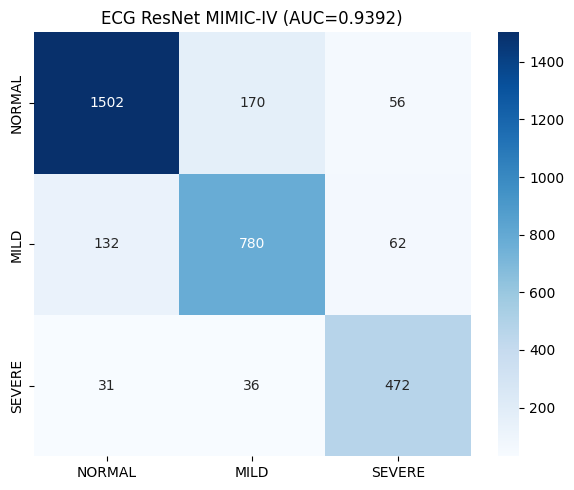

In [69]:
# Test evaluation cell run karo
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_preds, all_true, all_probs = [], [], []

with torch.no_grad():
    for ecg, y in test_loader:
        out   = model(ecg.to(device))
        probs = torch.softmax(out, dim=1).cpu().numpy()
        preds = out.argmax(1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_true.extend(y.numpy())

all_probs   = np.array(all_probs)
label_names = ['NORMAL', 'MILD', 'SEVERE']

print("── ECG-only Baseline Results ──")
print(classification_report(
    all_true, all_preds,
    target_names=label_names, digits=4
))

auc = roc_auc_score(
    all_true, all_probs,
    multi_class='ovr', average='macro'
)
print(f"Macro AUC-ROC : {auc:.4f}")

cm = confusion_matrix(all_true, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=label_names,
            yticklabels=label_names,
            cmap='Blues')
plt.title(f'ECG ResNet MIMIC-IV (AUC={auc:.4f})')
plt.tight_layout()
plt.savefig('ecg_mimic_results.png', dpi=150)
plt.show()